# Reviewer walkthrough — Option Hedging Optimization (Stochastic Control, Deep Learning)

**Purpose:** verify every number behind the resume points in ~3 minutes. This notebook only
*loads committed result files* — no training, no downloads. Full provenance: `CLAIMS.md`;
full verification: `REPRODUCING.md` (fresh-machine log: `results/fresh_machine_run.log`).


## Point 1 — *1.3k-param policy, differentiable-P&L training, mean–CVaR(95%) objective*
The training configuration and objective, from the committed results (the simulator is differentiable,
so the policy trains by direct gradient descent through simulated P&L — no policy-gradient machinery).

In [1]:
import json, glob, pandas as pd
lp = json.load(open("../results/learned_policy_results.json"))
print("objective/config:", json.dumps(lp["config"], indent=1)[:400])
side = sorted(glob.glob("../results/weights/*.json"))[0]
sc = json.load(open(side))
n_params = sc.get("n_params") or sc.get("model_config", {}).get("n_params", "see model_config below")
print("\nweights sidecar:", side.split('/')[-1], "| params:", n_params)
sc.get("model_config", sc)

objective/config: {
 "boot_seed": 424,
 "lambda": 1.0,
 "n_boot": 500,
 "path_set": "TEST",
 "path_set_sha256": "2d031716b16fa24eae2c3c43dbe1a659c678ee954d5aad4625f91f6e2abc7c07",
 "seeds": [
  0,
  1,
  2,
  3,
  4
 ]
}

weights sidecar: ablation_c20_s0.pt.json | params: see model_config below


{'best_epoch': 119,
 'best_val_objective': 2.204310417175293,
 'cost_bps': 20.0,
 'epochs_trained': 120,
 'hidden': [32, 32],
 'market': {'gbm': {'mu': 0.0, 's0': 100.0, 'sigma': 0.2},
  'horizon': 0.25,
  'n_steps': 63,
  'strike': 100.0},
 'mask_inventory': True,
 'max_epochs': 120,
 'objective': {'alpha': 0.95, 'kind': 'mean_cvar', 'lam': 1.0},
 'optimizer': {'batch_size': 8192,
  'lr': 0.003,
  'name': 'adam',
  'schedule': 'cosine',
  'train_dtype': 'float32'},
 'patience': 12,
 'seed': 0,
 'smoke': False,
 'torch_version': '2.13.0+cpu',
 'train_curve': [7.737790731283335,
  6.576298566964956,
  4.4158806434044475,
  3.0572777344630313,
  3.028673997292152,
  2.9202528183276835,
  2.852769503226647,
  2.8016686622913065,
  2.7387250570150523,
  2.6612213208125186,
  2.5749363899230957,
  2.474735351709219,
  2.39866880270151,
  2.3578420785757213,
  2.3403865740849423,
  2.3379970697256236,
  2.3351371655097375,
  2.332990884780884,
  2.3302404146928053,
  2.327900684796847,
  2.3

## Point 2 — *Lowest CVaR95 at every cost level; 9–13% below calibrated Whalley–Wilmott*
Frozen 100k-path TEST-set table: classical baselines are grid-calibrated per cost level on the same
objective (`results/baseline_calibration.json`) — the comparison is against their best, not defaults.

In [2]:
bt = json.load(open("../results/baseline_table.json"))["rows"]
per = json.load(open("../results/learned_policy_results.json"))["per_cost"]
piv = pd.DataFrame(bt).pivot(index="cost_bps", columns="strategy", values="cvar95").round(4)
piv["learned(5-seed mean)"] = [round(per[f"{c:.1f}"]["across_seeds"]["cvar95"]["mean"], 4) if f"{c:.1f}" in per else None for c in piv.index]
ww = [c for c in piv.columns if "whalley" in c or "wilmott" in c][0]
lel = [c for c in piv.columns if "leland" in c][0]
piv["vs WW %"] = (100*(piv[ww]-piv["learned(5-seed mean)"])/piv[ww]).round(1)
piv["vs Leland %"] = (100*(piv[lel]-piv["learned(5-seed mean)"])/piv[lel]).round(1)
display(piv)
trained = piv.dropna(subset=["learned(5-seed mean)"])
classical = trained[[c for c in piv.columns if c not in ("learned(5-seed mean)", "vs WW %", "vs Leland %")]]
assert (trained["learned(5-seed mean)"] <= classical.min(axis=1) + 1e-9).all()
assert trained["vs WW %"].between(8.5, 14).all()
print("ASSERT OK: learned policy lowest CVaR95 at every trained cost level; 9-13% below calibrated WW")

strategy,bs_delta,leland,whalley_wilmott,learned(5-seed mean),vs WW %,vs Leland %
cost_bps,,,,,,
0.0,1.0017,1.0017,1.0017,NaN,NaN,NaN
5.0,1.2365,1.0635,1.2177,1.0542,13.4,0.9
20.0,1.9683,1.6067,1.8006,1.5781,12.4,1.8
50.0,3.5041,2.7287,2.7940,2.5408,9.1,6.9


ASSERT OK: learned policy lowest CVaR95 at every trained cost level; 9-13% below calibrated WW


### The correctness plot (visual anchor)
Before any comparison is believed, the hedging engine must pass its analytic sanity check: with zero
costs, Black-Scholes delta-hedging error must vanish as rebalancing frequency grows, at the theoretical
O(1/√N) rate. The committed figure below is that check — the engine reproduces the textbook.

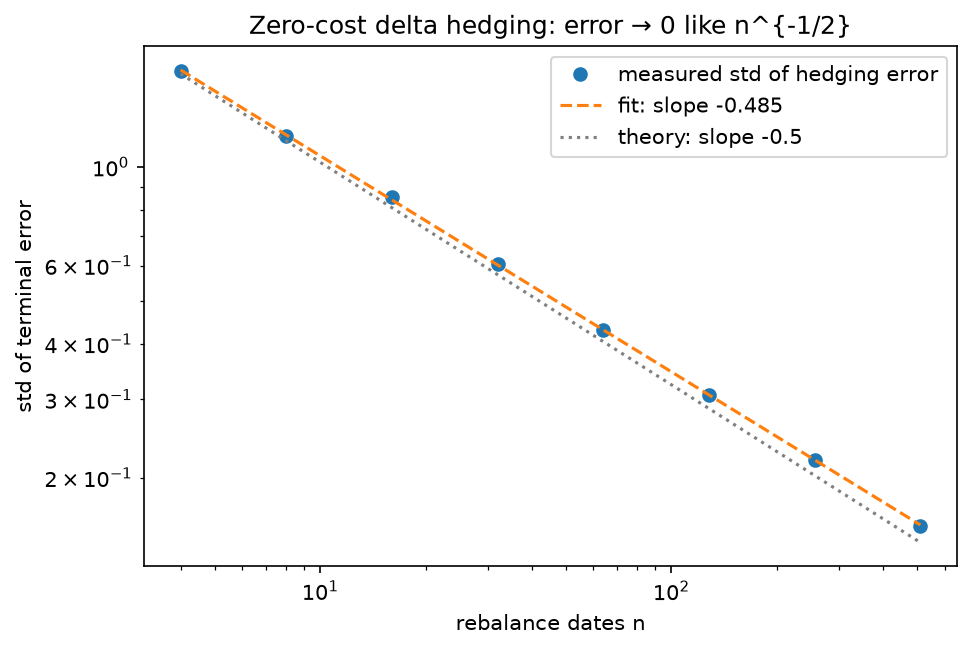

In [3]:
from IPython.display import Image, display
display(Image("../results/convergence_check.png"))

## Point 3 — *Advantage widened ~2.3× on real NIFTY returns (H3: honest surprise)*
Policies trained on GBM, evaluated off-distribution. The paired CVaR advantage vs calibrated WW
persists on Heston and *grows* on block-bootstrapped NIFTY — pre-registered H3 predicted shrinkage,
so the formal verdict is "not supported", in the good direction.

In [4]:
ms = json.load(open("../results/misspecification.json"))
h = ms["sets"]["heston"]["cvar_diff_mean"]; n = ms["sets"]["nifty_bootstrap"]["cvar_diff_mean"] if "nifty_bootstrap" in ms["sets"] else ms["sets"][[k for k in ms["sets"] if "nifty" in k][0]]["cvar_diff_mean"]
print(f"paired CVaR advantage vs calibrated WW:  Heston {h:.4f}   NIFTY {n:.4f}   ratio {n/h:.2f}x")
print("advantage never inverts:", ms["not_inverted"], "| pre-registered 'shrinks' verdict:", ms["h3_verdict"], "(it widened)")
assert ms["not_inverted"] and n < h < 0 and 2.0 < n/h < 2.6
print("ASSERT OK")

paired CVaR advantage vs calibrated WW:  Heston -0.1634   NIFTY -0.3754   ratio 2.30x
advantage never inverts: True | pre-registered 'shrinks' verdict: not supported (it widened)
ASSERT OK


## Point 4 — *Pre-registered negative on band recovery; exact reproducibility*
The 'policy rediscovers the Whalley–Wilmott band' claim was **quantified** (no-trade-region IoU +
width-monotonicity), and rejected: band-*like* (width rises with cost in 5/5 seeds) but not *the* band
(IoU far below the 0.5 threshold). Committed weights reproduce published metrics to 1e-6 on CPU
(`tests/`, `results/fresh_machine_run.log`).

In [5]:
ba = json.load(open("../results/band_analysis.json"))
ious = {c: round(v["iou_mean"], 3) for c, v in ba["per_cost"].items()}
print("IoU vs calibrated WW band, by cost:", ious)
print("width monotone in cost:", ba["seeds_monotone_count"], "/ 5 seeds | H2 verdict:", ba["h2_verdict"])
assert max(v["iou_mean"] for v in ba["per_cost"].values()) < 0.14 and ba["seeds_monotone_count"] == 5
print("ASSERT OK: band-like (monotone widths) but claim honestly rejected (IoU << threshold)")

IoU vs calibrated WW band, by cost: {'20.0': 0.058, '5.0': 0.035, '50.0': 0.137}
width monotone in cost: 5 / 5 seeds | H2 verdict: not supported
ASSERT OK: band-like (monotone widths) but claim honestly rejected (IoU << threshold)


---
**Resume-point → evidence:** P1/P2 → cells above + `notebooks/03_baseline_results.ipynb`, `04_learned_policy.ipynb`;
P3 → `notebooks/05_analysis.ipynb`; P4 → `results/band_analysis.json`, reproduction test in `tests/`.
Full check: `uv sync --frozen && uv run pytest -q` (65 tests).